# Decision Trees and Random Forests in Python

Reference: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

![](https://storage.googleapis.com/kaggle-datasets-images/3102947/5344155/d4f2d9d63736fff7b6ba10f73774752e/dataset-cover.png?t=2023-04-08-06-42-24)

# Install this package before starting this lab

## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Get the Data

In [ ]:
df = pd.read_csv('https://github.com/pvateekul/CU-DEPA-PracticalAI/raw/main/datasets/diabetes.csv')

## EDA

We'll just check out a simple pairplot for this small dataset.

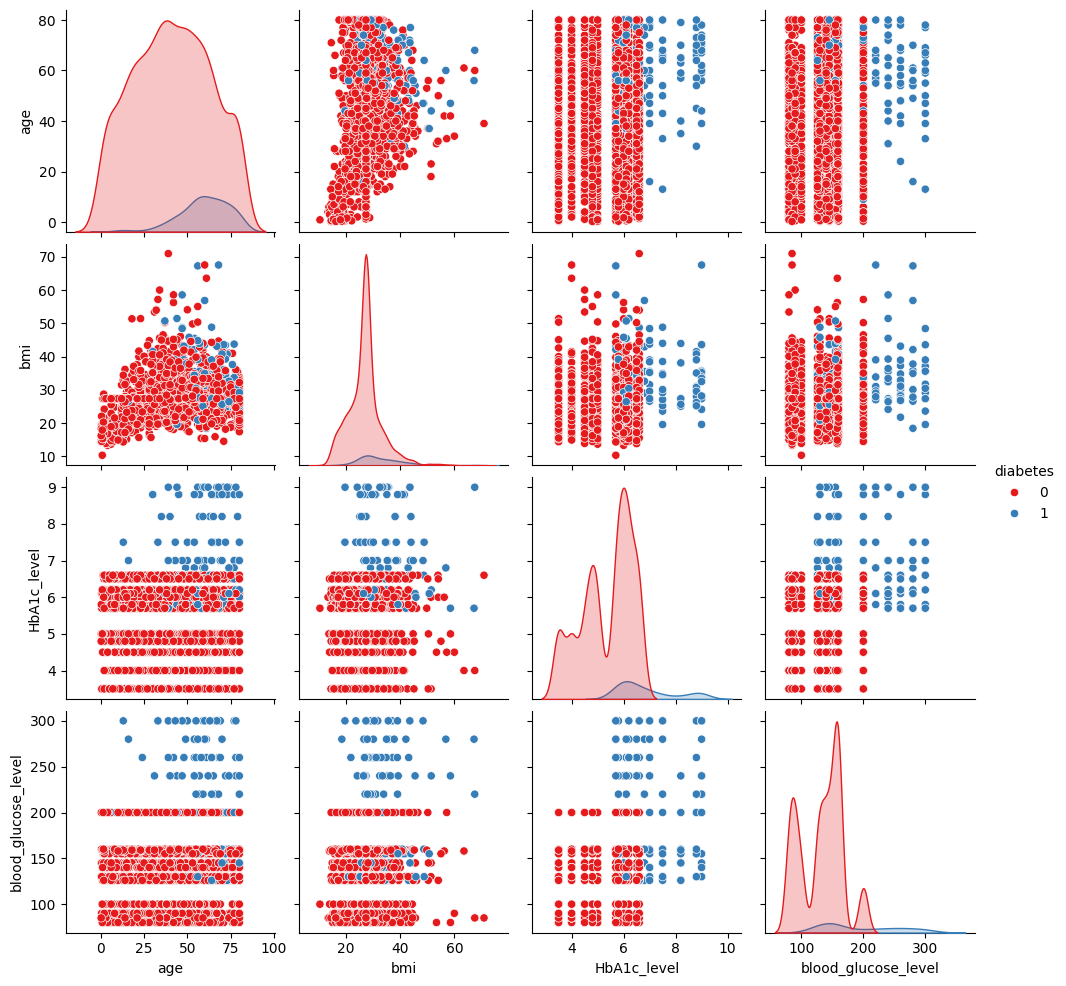

In [10]:
sns.pairplot(df,hue='diabetes',palette='Set1')

## Train Test Split

Let's split up the data into a training set and a test set!

In [11]:
from sklearn.model_selection import train_test_split

In [31]:
X = df.drop('diabetes',axis=1)
y = df['diabetes']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.30, random_state=30)

## Decision Trees

We'll start just by training a single decision tree.

http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [33]:
from sklearn.tree import DecisionTreeClassifier

In [34]:
dtree = DecisionTreeClassifier(min_samples_leaf=10, max_depth=3, criterion='entropy')

In [35]:
dtree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
import pickle
filename = 'model.sav'
pickle.dump(dtree, open(filename, 'wb'))

## Prediction and Evaluation

Let's evaluate our decision tree.

In [37]:
dtree = pickle.load(open(filename,'rb'))
dtree

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
predictions = dtree.predict(X_test)

In [39]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
print(classification_report(y_test,predictions, target_names=['absent', 'present'], digits=4))

              precision    recall  f1-score   support

      absent     0.9665    1.0000    0.9830       549
     present     1.0000    0.6275    0.7711        51

    accuracy                         0.9683       600
   macro avg     0.9833    0.8137    0.8770       600
weighted avg     0.9694    0.9683    0.9650       600



In [41]:
print(confusion_matrix(y_test,predictions,labels=[0,1]))

[[549   0]
 [ 19  32]]


## Tree Visualization

Scikit learn actually has some built-in visualization capabilities for decision trees, you won't use this often and it requires you to install the pydot library, but here is an example of what it looks like and the code to execute this:

[Text(0.6666666666666666, 0.875, 'x[3] <= 210.0\nentropy = 0.42\nsamples = 1400\nvalue = [1281.0, 119.0]'),
 Text(0.5, 0.625, 'x[2] <= 6.7\nentropy = 0.294\nsamples = 1351\nvalue = [1281, 70]'),
 Text(0.5833333333333333, 0.75, 'True  '),
 Text(0.3333333333333333, 0.375, 'x[2] <= 5.35\nentropy = 0.196\nsamples = 1321\nvalue = [1281, 40]'),
 Text(0.16666666666666666, 0.125, 'entropy = 0.0\nsamples = 561\nvalue = [561, 0]'),
 Text(0.5, 0.125, 'entropy = 0.297\nsamples = 760\nvalue = [720, 40]'),
 Text(0.6666666666666666, 0.375, 'entropy = 0.0\nsamples = 30\nvalue = [0, 30]'),
 Text(0.8333333333333334, 0.625, 'entropy = 0.0\nsamples = 49\nvalue = [0, 49]'),
 Text(0.75, 0.75, '  False')]

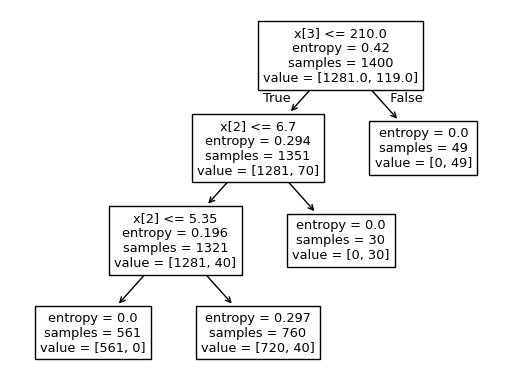

In [42]:
from sklearn import tree
tree.plot_tree(dtree)

In [43]:
print(X.columns) # feature names
print(y.unique().tolist()) # class names

Index(['age', 'bmi', 'HbA1c_level', 'blood_glucose_level'], dtype='object')
[0, 1]


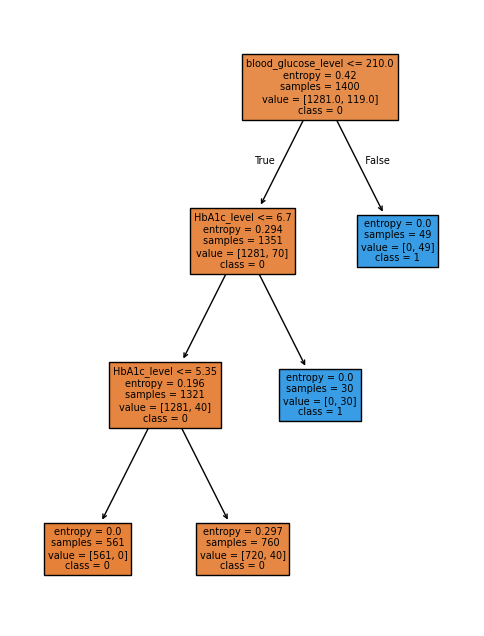

In [44]:
fn=X.columns # feature names
cn=y.unique().tolist() # class names
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (6,8), dpi=100)
tree.plot_tree(dtree,
               feature_names = fn,
               class_names=[str(cn[0]),str(cn[1])],
               filled = True);
fig.savefig('imagename.png')

# GridSearchCV

list of parameters that can be adjusted

In [57]:
dtree = DecisionTreeClassifier()
dtree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

param_grid= {'criterion':['entropy', 'gini'],
            'max_depth': [1,2,3,4,5,6,7,8,9,10],
            'min_samples_leaf':[1,2,3,4,5,6,7,8,9,10],
            'random_state':[0]}
gs_pipeline = GridSearchCV(dtree, param_grid, cv=StratifiedKFold(n_splits=5), scoring='f1')
gs_pipeline.fit(X_train, y_train)
print("Best parameter set: "+str(gs_pipeline.best_params_))

Best parameter set: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 8, 'random_state': 0}


In [69]:
y_pred_gs = gs_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_gs, target_names=['absent', 'present'], digits=4))
print(confusion_matrix(y_test,y_pred_gs,labels=[0,1]))

              precision    recall  f1-score   support

      absent     0.9682    0.9982    0.9830       549
     present     0.9706    0.6471    0.7765        51

    accuracy                         0.9683       600
   macro avg     0.9694    0.8226    0.8797       600
weighted avg     0.9684    0.9683    0.9654       600

[[548   1]
 [ 18  33]]
